In [ ]:
!pip install networkx matplotlib numpy scipy

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from scipy.integrate import odeint
import random

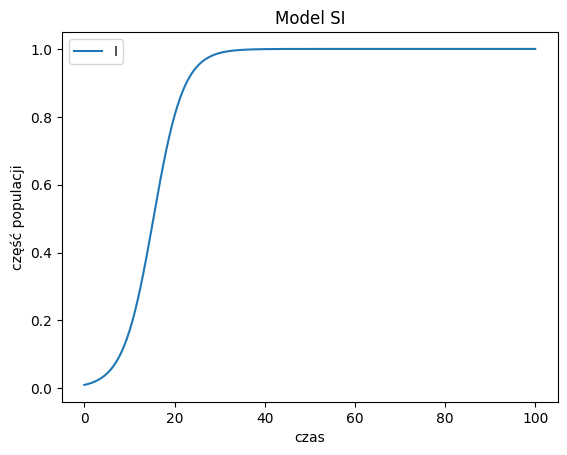

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

beta = 0.3

def si_model(i, t, beta):
    return beta * i * (1 - i)

i0 = 0.01
t = np.linspace(0, 100, 500)

i = odeint(si_model, i0, t, args=(beta,))
i = i.flatten()

plt.figure()
plt.plot(t, i, label="I")
plt.xlabel("czas")
plt.ylabel("część populacji")
plt.title("Model SI")
plt.legend()
plt.show()

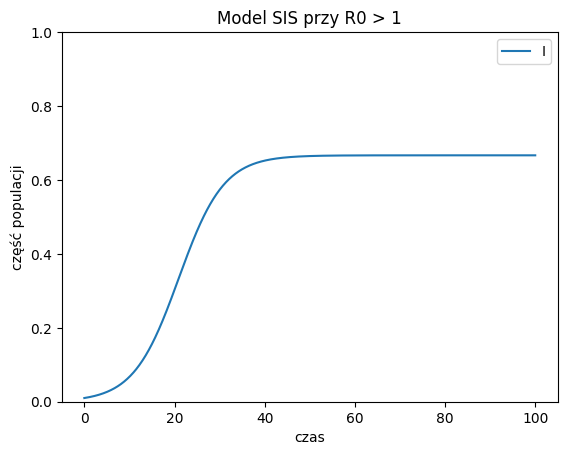

In [ ]:
beta = 0.3
mu = 0.1

def sis_model(i, t, beta, mu):
    return beta * i * (1 - i) - mu * i

i0 = 0.01
t = np.linspace(0, 100, 1000)

i = odeint(sis_model, i0, t, args=(beta, mu))
i = i.flatten()

plt.figure()
plt.plot(t, i, label="I")
plt.xlabel("czas")
plt.ylabel("część populacji")
plt.ylim(0, 1)  # <-- to dodajemy
# plt.xlim(0, 50)  # <-- to dodajemy
plt.title("Model SIS przy R0 > 1")
plt.legend()
plt.show()

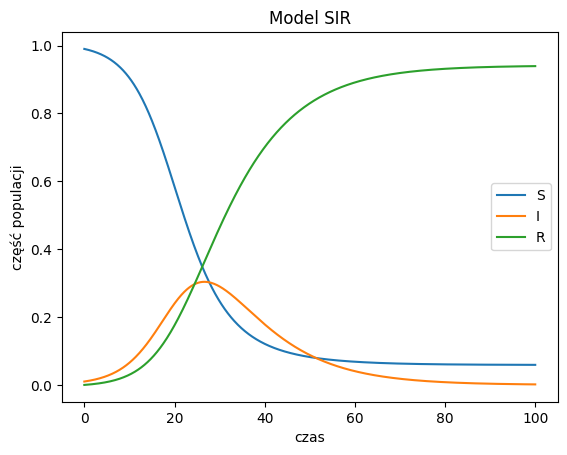

In [ ]:
beta = 0.3
mu = 0.1

def sir_model(y, t, beta, mu):
    s, i, r = y
    dsdt = -beta * s * i
    didt = beta * s * i - mu * i
    drdt = mu * i
    return [dsdt, didt, drdt]

# warunki początkowe
s0, i0, r0 = 0.99, 0.01, 0.0
t = np.linspace(0, 100, 1000)

# rozwiązanie
sol = odeint(sir_model, [s0, i0, r0], t, args=(beta, mu))
s, i, r = sol.T

# wykres
plt.figure()
plt.plot(t, s, label="S")
plt.plot(t, i, label="I")
plt.plot(t, r, label="R")
plt.xlabel("czas")
plt.ylabel("część populacji")
plt.legend()
plt.title("Model SIR")
plt.show()

⟨k⟩ random = 4.21
⟨k⟩ scale-free = 3.96


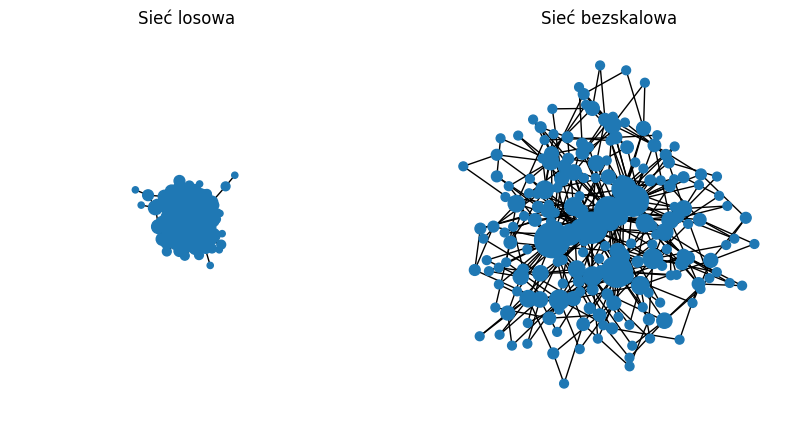

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

N = 200
p = 4/(N-1)
# sieci
G_random = nx.erdos_renyi_graph(N, p)
G_sf = nx.barabasi_albert_graph(N, 2)

def draw_graph(G, title):
    pos = nx.spring_layout(G, seed=42)

    degrees = dict(G.degree())
    node_sizes = [degrees[n]*20 for n in G.nodes()]

    nx.draw(G, pos,
            node_size=node_sizes,
            with_labels=False)

    plt.title(title)

plt.figure(figsize=(10,5))

plt.subplot(121)
draw_graph(G_random, "Sieć losowa")

plt.subplot(122)
draw_graph(G_sf, "Sieć bezskalowa")

def compute_k_avg(G):
    return sum(dict(G.degree()).values()) / len(G.nodes())

print("⟨k⟩ random =", compute_k_avg(G_random))
print("⟨k⟩ scale-free =", compute_k_avg(G_sf))

plt.show()

In [ ]:
import random

def simulate_SI(G, beta, steps):
    state = {node: 0 for node in G.nodes()}  # 0=S, 1=I

    # początkowa infekcja
    patient_zero = random.choice(list(G.nodes()))
    state[patient_zero] = 1

    history = []

    for t in range(steps):
        new_state = state.copy()

        for node in G.nodes():
            if state[node] == 1:
                for neigh in G.neighbors(node):
                    if state[neigh] == 0 and random.random() < beta:
                        new_state[neigh] = 1

        state = new_state
        history.append(state.copy())

    return history

In [ ]:
def plot_snapshots(G, history, times, title):
    pos = nx.spring_layout(G, seed=42, k=0.3, iterations=100)

    plt.figure(figsize=(12,3))

    for i, t in enumerate(times):
        plt.subplot(1, len(times), i+1)

        state = history[t]
        colors = ["red" if state[n]==1 else "lightgray" for n in G.nodes()]

        degrees = dict(G.degree())
        node_sizes = [10 + np.sqrt(degrees[n])*10 for n in G.nodes()]

        nx.draw(G, pos,
                node_color=colors,
                node_size=node_sizes,
                edge_color="gray",
                width=0.3,
                alpha=0.7,
                with_labels=False)

        plt.title(f"t={t}")

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

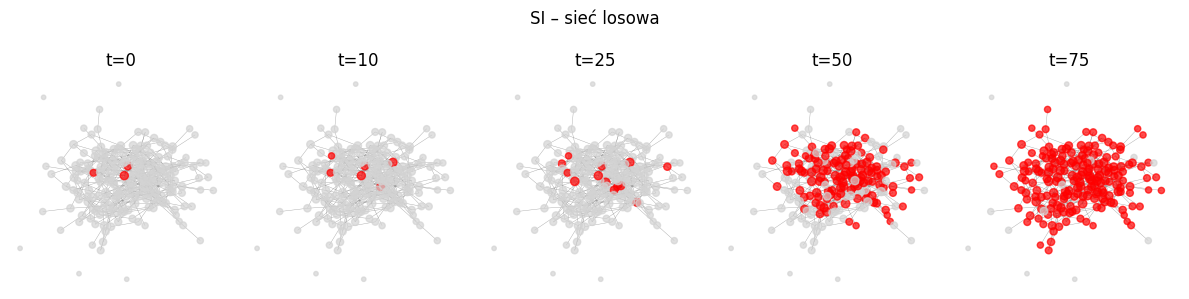

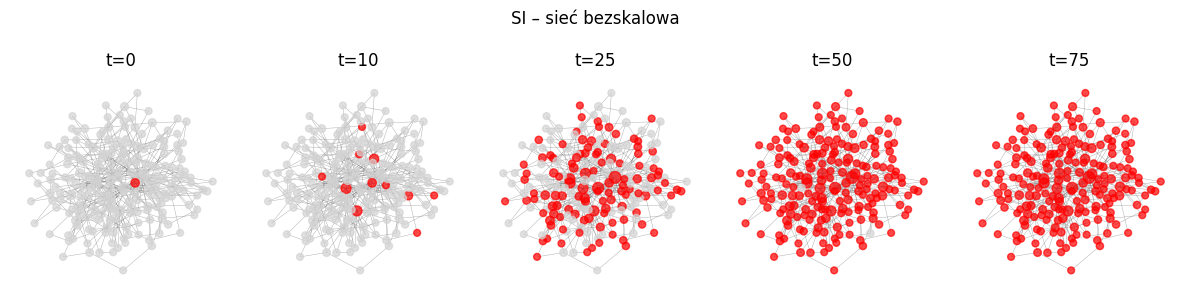

In [ ]:
beta = 0.05
steps = 100

hist_random = simulate_SI(G_random, beta, steps)
hist_sf = simulate_SI(G_sf, beta, steps)

times = [0, 10, 25, 50, 75]

plot_snapshots(G_random, hist_random, times, "SI – sieć losowa")
plot_snapshots(G_sf, hist_sf, times, "SI – sieć bezskalowa")

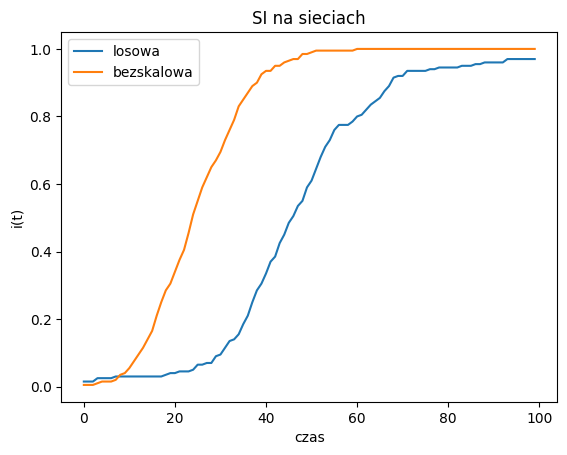

In [ ]:
def infected_fraction(history):
    return [sum(state.values())/len(state) for state in history]

i_rand = infected_fraction(hist_random)
i_sf = infected_fraction(hist_sf)

plt.figure()
plt.plot(i_rand, label="losowa")
plt.plot(i_sf, label="bezskalowa")
plt.xlabel("czas")
plt.ylabel("i(t)")
plt.legend()
plt.title("SI na sieciach")
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import random

N = 200

p = 6/(N-1)
G_random = nx.erdos_renyi_graph(N, p)
G_sf = nx.barabasi_albert_graph(N, 3)

def compute_k_avg(G):
    return sum(dict(G.degree()).values()) / len(G.nodes())

print("⟨k⟩ random =", compute_k_avg(G_random))
print("⟨k⟩ scale-free =", compute_k_avg(G_sf))

⟨k⟩ random = 5.95
⟨k⟩ scale-free = 5.91


In [ ]:
def simulate_SIS_stable(G, beta, mu, steps, initial_fraction=0.05):
    state = {node: 0 for node in G.nodes()}

    # 🔥 więcej niż jeden zakażony (klucz!)
    initial_nodes = random.sample(list(G.nodes()), int(initial_fraction * len(G)))
    for n in initial_nodes:
        state[n] = 1

    history = []

    for t in range(steps):
        new_state = state.copy()

        for node in G.nodes():
            if state[node] == 1:
                # zdrowienie
                if random.random() < mu:
                    new_state[node] = 0

                # zarażanie (nie w else → oba mogą zajść)
                for neigh in G.neighbors(node):
                    if state[neigh] == 0 and random.random() < beta:
                        new_state[neigh] = 1

        state = new_state
        history.append(state.copy())

    return history


def infected_fraction(history):
    return [sum(state.values())/len(state) for state in history]

In [ ]:
def plot_snapshots(G, history, times, title):
    pos = nx.spring_layout(G, seed=42, k=0.35, iterations=100)

    plt.figure(figsize=(12,3))

    for i, t in enumerate(times):
        plt.subplot(1, len(times), i+1)

        state = history[t]
        colors = ["red" if state[n]==1 else "lightgray" for n in G.nodes()]

        degrees = dict(G.degree())
        node_sizes = [10 + np.sqrt(degrees[n])*12 for n in G.nodes()]

        nx.draw(G, pos,
                node_color=colors,
                node_size=node_sizes,
                edge_color="gray",
                width=0.3,
                alpha=0.7,
                with_labels=False)

        plt.title(f"t={t}")

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

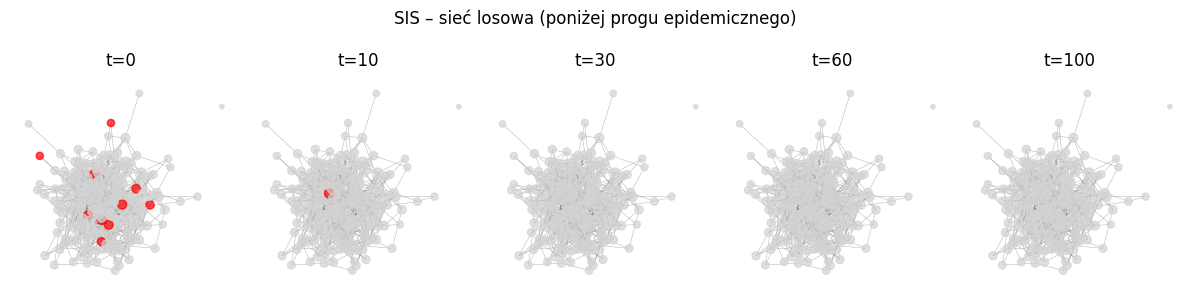

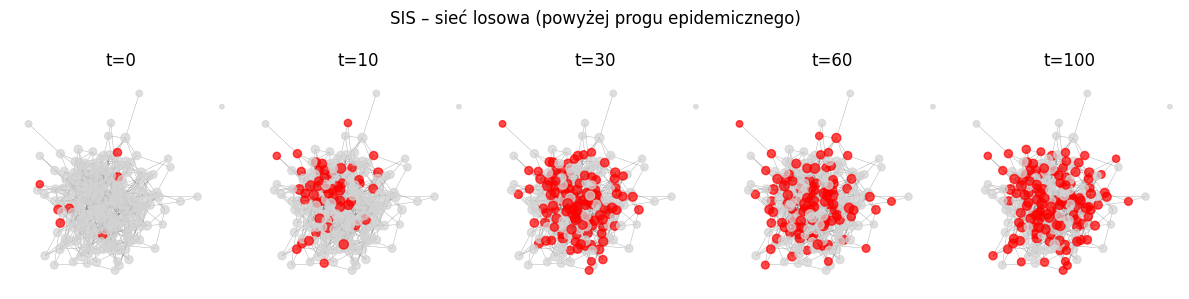

In [ ]:
steps = 120
times = [0, 10, 30, 60, 100]

mu = 0.2

# ❌ poniżej progu
hist_rand_low = simulate_SIS_stable(G_random, beta=0.028, mu=mu, steps=steps)

# ✅ powyżej progu
hist_rand_high = simulate_SIS_stable(G_random, beta=0.08, mu=mu, steps=steps)

plot_snapshots(G_random, hist_rand_low, times,
               "SIS – sieć losowa (poniżej progu epidemicznego)")

plot_snapshots(G_random, hist_rand_high, times,
               "SIS – sieć losowa (powyżej progu epidemicznego)")

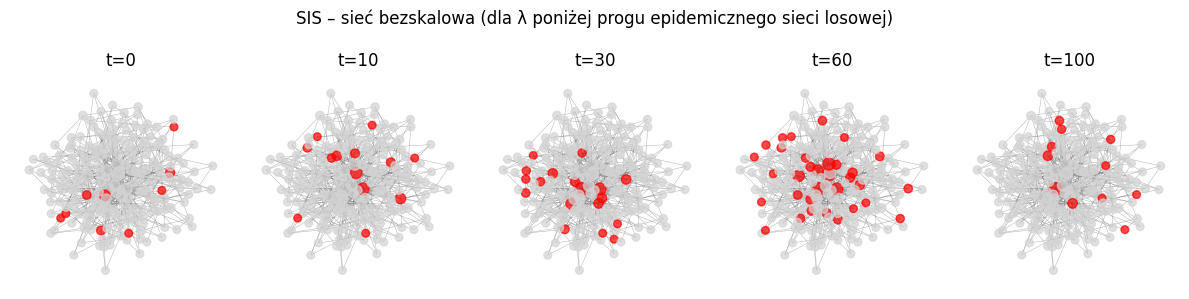

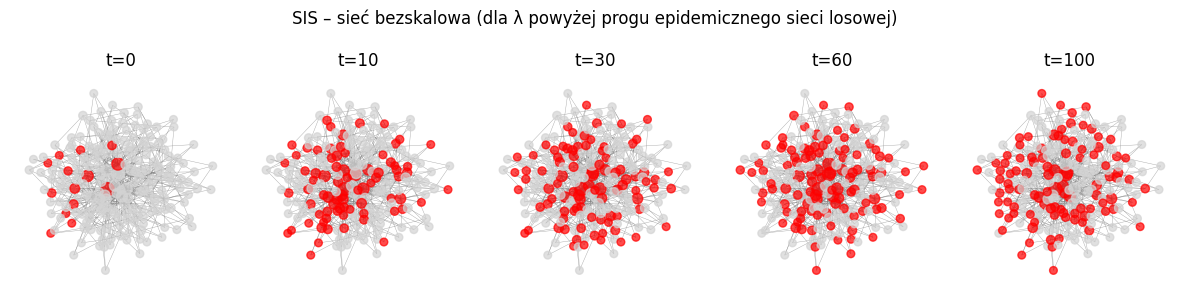

In [ ]:
# 🔴 małe λ (ale NIE zdycha!)
hist_sf_low = simulate_SIS_stable(G_sf, beta=0.028, mu=mu, steps=steps)

# 🔥 większe λ
hist_sf_high = simulate_SIS_stable(G_sf, beta=0.08, mu=mu, steps=steps)

plot_snapshots(G_sf, hist_sf_low, times,
               "SIS – sieć bezskalowa (dla λ poniżej progu epidemicznego sieci losowej)")

plot_snapshots(G_sf, hist_sf_high, times,
               "SIS – sieć bezskalowa (dla λ powyżej progu epidemicznego sieci losowej)")

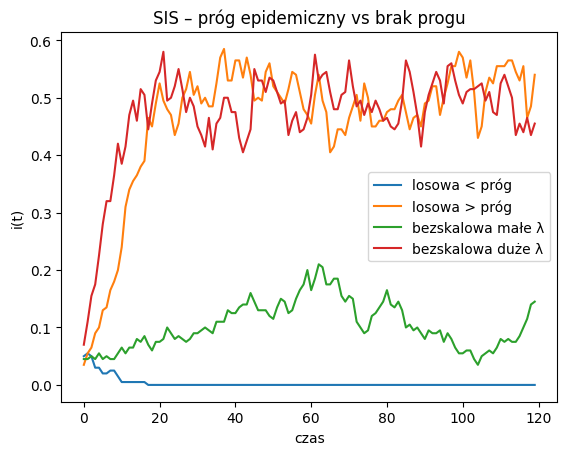

In [ ]:
plt.figure()

plt.plot(infected_fraction(hist_rand_low), label="losowa < próg")
plt.plot(infected_fraction(hist_rand_high), label="losowa > próg")
plt.plot(infected_fraction(hist_sf_low), label="bezskalowa małe λ")
plt.plot(infected_fraction(hist_sf_high), label="bezskalowa duże λ")

plt.xlabel("czas")
plt.ylabel("i(t)")
plt.legend()
plt.title("SIS – próg epidemiczny vs brak progu")

plt.show()